В цьому домашньому завданні ми з вами побудуємо повноцінне ML-рішення реальної ML-задачі. Ви вже маєте всі знання, які для цього потрібні. Дотримуйтесь інструкцій, та користуйтесь матеріалами лекцій, аби виконувати завдання. Тут інструкції будуть детальні, а в подільших завданнях - будуть ставати все менш детальними, аби ви вже починали самостійно структурувати ML-проєкт і до кінця курсу для вас розвʼязати будь-яку ML–задачу було eazy-breezy.

## Dataset

Будемо працювати з набором даних `cars.csv`, який описує автомобілі і їх ціну у індійських рупіях :) Мета - передбачити ціну авто за його характеристиками. Опис набору даних:

| Назва рядка            | Опис                                                                                                                                                 |
|------------------------|--------------------------------------------------------------------------------------------------------------------------------------------------------|
| Car_ID                 | Унікальний ідентифікатор для кожного оголошення про автомобіль.                                                                                         |
| Brand                  | Бренд або виробник автомобіля (наприклад, Toyota, Honda, Ford тощо).                                                                                     |
| Model                  | Модель автомобіля (наприклад, Camry, Civic, Mustang тощо).                                                                                               |
| Year                   | Рік виготовлення автомобіля.                                                                                                                            |
| Kilometers_Driven      | Загальний пробіг автомобіля у кілометрах.                                                                                                               |
| Fuel_Type              | Тип палива, який використовує автомобіль (наприклад, бензин, дизель, електро тощо).                                                                      |
| Transmission           | Тип трансмісії автомобіля (наприклад, механічна, автоматична).                                                                                           |
| Owner_Type             | Кількість попередніх власників автомобіля (наприклад, перший, другий, третій).                                                                           |
| Mileage                | Паливна ефективність автомобіля у кілометрах на літр.                                                                                                   |
| Engine                 | Об'єм двигуна автомобіля в кубічних сантиметрах (CC).                                                                                                   |
| Power                  | Максимальна потужність автомобіля в кінських силах (bhp).                                                                                               |
| Seats                  | Кількість місць в автомобілі.                                                                                                                           |
| Price                  | Вартість автомобіля в INR (індійські рупії), що є цільовою змінною для прогнозування.                                                                   |

# Імпорти

Для зручності рекомендую всі імпорти розмістити тут нагорі, аби коли ви перезавантажували ноутбук, одразу можна було в один запуск клітинки імпортувати всі потрібні бібліотеки.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

from google.colab import drive

pd.set_option('display.max.rows',130)
pd.set_option('display.max.columns',130)
pd.set_option('float_format', '{:.2f}'.format)

In [2]:
def df_type_analysis(df):
    dtypes = df.dtypes

    object_columns = df.select_dtypes(include='object').columns
    object_types_analysis = {}
    category_info = {}

    for col in object_columns:
        types_in_column = df[col].map(type).value_counts()
        object_types_analysis[col] = types_in_column

    for col in object_columns:
        unique_vals = df[col].dropna().unique()
        category_info[col] = {
            "n_unique": len(unique_vals),
            "unique_vals": unique_vals[:10]
        }

    numeric_columns = df.select_dtypes(include='number').columns
    n_numeric = len(numeric_columns)
    n_categorical = len(object_columns)

    print("Типи всіх колонок:")
    print(dtypes)
    print("______________\n")

    print(f"Numeric columns: {n_numeric}     Categorical columns: {n_categorical}")
    print("______________\n")

    print("Аналіз типів значень у категорійних колонках:\n")
    for col, type_counts in object_types_analysis.items():
        print(f"['{col:<15}']", end='')
        for val_type, count in type_counts.items():
            print(f"   - {val_type.__name__}: {count} шт.")

    print("______________\n")

    print("Унікальні значення для категорійних колонок:")
    for col, info in category_info.items():
        print(f"\n['{col}'] — {info['n_unique']} унікальних значень:")
        for val in info["unique_vals"]:
            print(f"   - {val}")
        if info["n_unique"] > 10:
            print("   ... (показано перші 10)")


# Знайомство з даними

**Завдання 1.** Завантажте набір даних `cars.csv` в pandas.DataFrame. Виведіть перші 5 записів.

In [3]:
drive.mount('/content/drive')
!ls drive/MyDrive/ML/MLFH\ 3.0/data/cars/

Mounted at /content/drive
cars.csv


In [4]:
cars_df = pd.read_csv("/content/drive/MyDrive/ML/MLFH 3.0/data/cars/cars.csv")
cars_df.head()

,Car_ID,Brand,Model,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,Price
0,1,Toyota,Corolla,2018,50000,Petrol,Manual,First,15,1498,108,5,800000
1,2,Honda,Civic,2019,40000,Petrol,Automatic,Second,17,1597,140,5,1000000
2,3,Ford,Mustang,2017,20000,Petrol,Automatic,First,10,4951,395,4,2500000
3,4,Maruti,Swift,2020,30000,Diesel,Manual,Third,23,1248,74,5,600000
4,5,Hyundai,Sonata,2016,60000,Diesel,Automatic,Second,18,1999,194,5,850000


**Завдання 2.** Виведіть типи даних колонок даних, а також дослідіть, які по факту типи даних мають записи в кожній колонці (тип `object` може містити різні типи даних) і скільки значень є в кожній категоріальній колонці.

Напишіть висновок, скільки в наборі даних числових та категоріальних колонок кожного з трьох різних типів (бінарна, мільтикатегоріальна без порядку, мультикатегоріальна з порядком). Шаблон висновку

```
В наборі даних 10 числових і 10 категоріальних колонок з них
- 2 бінарні (мають лише 2 значення)
- 6 мультикатегоріальних (більше 2х значень) зі значеннями, для яких немає відношення порядку
- 2 колонки, в яких можна встановити відношення порядку (наприклад Small<Medium<Large)
```

Якщо не знаєте, як це зробити з `pandas` - ось підказка, які методи можуть допомогти вам виконати це завдання

- pandas.DataFrame.info()
- pandas.DataFrame.dtypes
- pandas.DataFrame.loc[...]
- pandas.DataFrame.select_dtypes(...)
- pandas.Series.unique()
- pandas.Series.nunique()

Детальніше ознайомитись з кожним ви можете в [документації](https://pandas.pydata.org/docs/reference/frame.html), або написати в окремій клітинці знак питання і назву методу (тільки приберіть це перед здачею, бо перегляд документації - не допомагає зрозуміти дані і хід думок, а Ваша робота - це як презентація замовнику зробленої задачі).


In [5]:
cars_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Car_ID             100 non-null    int64 
 1   Brand              100 non-null    object
 2   Model              100 non-null    object
 3   Year               100 non-null    int64 
 4   Kilometers_Driven  100 non-null    int64 
 5   Fuel_Type          100 non-null    object
 6   Transmission       100 non-null    object
 7   Owner_Type         100 non-null    object
 8   Mileage            100 non-null    int64 
 9   Engine             100 non-null    int64 
 10  Power              100 non-null    int64 
 11  Seats              100 non-null    int64 
 12  Price              100 non-null    int64 
dtypes: int64(8), object(5)
memory usage: 10.3+ KB


In [6]:
unique_values = cars_df.nunique()
unique_values

,0
Car_ID,100
Brand,11
Model,58
Year,6
Kilometers_Driven,18
Fuel_Type,2
Transmission,2
Owner_Type,3
Mileage,15
Engine,36


In [7]:
df_type_analysis(cars_df)

Типи всіх колонок:
Car_ID                int64
Brand                object
Model                object
Year                  int64
Kilometers_Driven     int64
Fuel_Type            object
Transmission         object
Owner_Type           object
Mileage               int64
Engine                int64
Power                 int64
Seats                 int64
Price                 int64
dtype: object
______________

Numeric columns: 8     Categorical columns: 5
______________

Аналіз типів значень у категорійних колонках:

['Brand          ']   - str: 100 шт.
['Model          ']   - str: 100 шт.
['Fuel_Type      ']   - str: 100 шт.
['Transmission   ']   - str: 100 шт.
['Owner_Type     ']   - str: 100 шт.
______________

Унікальні значення для категорійних колонок:

['Brand'] — 11 унікальних значень:
   - Toyota
   - Honda
   - Ford
   - Maruti
   - Hyundai
   - Tata
   - Mahindra
   - Volkswagen
   - Audi
   - BMW
   ... (показано перші 10)

['Model'] — 58 унікальних значень:
   - Corolla
   

**Висновок:**

В наборі даних **8 числових** (7 ознак + 1 айді колонка Car_ID, що не використовується в аналізі) і **5 категоріальних** колонок з них
- **2 бінарних** (мають лише 2 значення) - **Fuel_Type** та **Transmission**
- **2 мультикатегоріальних** (більше 2х значень) зі значеннями, для яких **немає відношення порядку** - **Brand** та **Model**
- **1 мультикатегоріальна** колонка, в яких **можна встановити відношення порядку** (First<Second<Third) - **Owner_Type**

**Завдання 3**. Розділіть дані на тренувальні і тест. Відведіть в тест 20%, поставте `random_state=12`. Ми будемо передбачати колонку `Price` - тож, вона є цільовою змінною. В результаті у Вас має бути 4 набори даних `X_train, X_test, y_train, y_test`.

Надалі ми всюди тренуємо методи для кодування, масштабування та саму модель тільки на тренувальних даних X_train (та y_train для моделі), а на тестувальних лише використовуємо вже навчені методи для кодування, масштабування і модель викликаючи в них `transform()` (для методів обробки даних) або `predict()` (для моделі).

І так само треба робити завжди.

In [8]:
X = cars_df.drop(columns='Price')
y = cars_df['Price']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=12
)

X_train.shape, X_test.shape, y_train.shape, y_test.shape

((80, 12), (20, 12), (80,), (20,))

**Завдання 4**. Кодуємо категоріальні колонки.

1. Закодуйте колонки з бінарними значеннями `Fuel_Type` і `Transmission` так, аби вони були у чисельному представленні і містили лише 0 так 1. Приклад був у лекції. Значення 1 нехай буде у категорії, яка містить більше значень в колонці.

2. Закодуйте колонку `Brand` з використанням `sklearn.preprocessing.OneHotEncoder` аналогічно до того, як ми робили це в лекції. Увага! Ми робимо виклик методу `Encoder.fit()` на тренувальних даних `X_train`, а на тестувальних тільки викликаємо `Encoder.transform()`. Додайте закодовані значення в набори даних `X_train`, `X_test`.

3. Колонку `Owner_Type` з використанням `sklearn.preprocessing.OrdinalEncoder` я закодую для вас. Проаналізуйте, що відбувається.

Колонка `Model` містять забагато значень для кодування в тому вигляді, як вона є зараз, з огляду на невелику кількість даних. Якщо ви бачите, як можна згрупувати значення в цій колонці скоротивши кількість унікальних значень до 3-5, то можете виконати ще цю трансформацію, використати цю колонку в моделі і отримати додаткову практику і бал, якщо все буде зроблено правильно. А якщо неправильно - то фідбек на Вашу роботу :)

**4.1 Fuel_Type, Transmission**


In [9]:
binary_columns = ['Fuel_Type', 'Transmission']

for column in binary_columns:

  value_counts = X[column].value_counts()
  mapping_codes = {value_counts.index[0]: 1, value_counts.index[1]: 0}

  X_train[f"{column}_Code"] = X_train[column].map(mapping_codes)
  X_test[f"{column}_Code"] = X_test[column].map(mapping_codes)

  print(f"For column ['{column}'] mapping code is {mapping_codes}")

For column ['Fuel_Type'] mapping code is {'Petrol': 1, 'Diesel': 0}
For column ['Transmission'] mapping code is {'Automatic': 1, 'Manual': 0}


**4.2 Brand з використанням sklearn.preprocessing.OneHotEncoder**

In [10]:
enc = OneHotEncoder()
enc.fit(X_train[['Brand']])
enc.categories_

[array(['Audi', 'BMW', 'Ford', 'Honda', 'Hyundai', 'Mahindra', 'Maruti',
        'Mercedes', 'Tata', 'Toyota', 'Volkswagen'], dtype=object)]

In [11]:
X_train[enc.categories_[0]] = enc.transform(X_train[['Brand']]).toarray()
X_test[enc.categories_[0]] = enc.transform(X_test[['Brand']]).toarray()

In [12]:
display(X_train.head()), display(X_test.head())

,Car_ID,Brand,Model,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,Fuel_Type_Code,Transmission_Code,Audi,BMW,Ford,Honda,Hyundai,Mahindra,Maruti,Mercedes,Tata,Toyota,Volkswagen
83,84,Volkswagen,T-Roc,2019,22000,Petrol,Automatic,Second,18,1498,148,5,1,1,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00
55,56,Audi,A5,2018,28000,Diesel,Automatic,First,17,1968,187,5,0,1,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
26,27,Audi,A6,2018,28000,Petrol,Automatic,First,15,1984,241,5,1,1,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
54,55,Volkswagen,Vento,2017,32000,Petrol,Manual,Second,18,1598,103,5,1,0,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00
19,20,Mercedes,GLC,2017,26000,Petrol,Automatic,Second,12,1991,241,5,1,1,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00


,Car_ID,Brand,Model,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,Fuel_Type_Code,Transmission_Code,Audi,BMW,Ford,Honda,Hyundai,Mahindra,Maruti,Mercedes,Tata,Toyota,Volkswagen
17,18,Audi,Q3,2016,38000,Petrol,Automatic,Second,15,1395,148,5,1,1,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
41,42,Hyundai,Santro,2019,26000,Petrol,Manual,Third,20,1086,68,5,1,0,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00
92,93,Volkswagen,Vento,2017,32000,Petrol,Manual,Second,18,1598,103,5,1,0,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00
14,15,Maruti,Ertiga,2020,18000,Petrol,Manual,First,19,1462,103,7,1,0,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00
68,69,Ford,Aspire,2019,26000,Petrol,Manual,Third,20,1194,94,5,1,0,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00


(None, None)

**4.3 Owner_Type з використанням sklearn.preprocessing.OrdinalEncoder**

In [13]:
from sklearn.preprocessing import OrdinalEncoder

ordenc = OrdinalEncoder(categories=[['First', 'Second', 'Third']]) # визначаємо порядок категорій
ordenc.fit(X_train[['Owner_Type']])

X_train['Owner_Type_Codes'] = ordenc.transform(X_train[['Owner_Type']])
X_test['Owner_Type_Codes'] = ordenc.transform(X_test[['Owner_Type']])

Очікуваний результат після трансформацій:

In [14]:
pd.set_option('display.max_columns', 100)
display(X_train.head()), display(X_test.head())

,Car_ID,Brand,Model,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,Fuel_Type_Code,Transmission_Code,Audi,BMW,Ford,Honda,Hyundai,Mahindra,Maruti,Mercedes,Tata,Toyota,Volkswagen,Owner_Type_Codes
83,84,Volkswagen,T-Roc,2019,22000,Petrol,Automatic,Second,18,1498,148,5,1,1,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,1.00
55,56,Audi,A5,2018,28000,Diesel,Automatic,First,17,1968,187,5,0,1,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
26,27,Audi,A6,2018,28000,Petrol,Automatic,First,15,1984,241,5,1,1,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
54,55,Volkswagen,Vento,2017,32000,Petrol,Manual,Second,18,1598,103,5,1,0,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,1.00
19,20,Mercedes,GLC,2017,26000,Petrol,Automatic,Second,12,1991,241,5,1,1,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,1.00


,Car_ID,Brand,Model,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,Fuel_Type_Code,Transmission_Code,Audi,BMW,Ford,Honda,Hyundai,Mahindra,Maruti,Mercedes,Tata,Toyota,Volkswagen,Owner_Type_Codes
17,18,Audi,Q3,2016,38000,Petrol,Automatic,Second,15,1395,148,5,1,1,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00
41,42,Hyundai,Santro,2019,26000,Petrol,Manual,Third,20,1086,68,5,1,0,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,2.00
92,93,Volkswagen,Vento,2017,32000,Petrol,Manual,Second,18,1598,103,5,1,0,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,1.00
14,15,Maruti,Ertiga,2020,18000,Petrol,Manual,First,19,1462,103,7,1,0,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00
68,69,Ford,Aspire,2019,26000,Petrol,Manual,Third,20,1194,94,5,1,0,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,2.00


(None, None)

З такою великою кількістю унікальних моделей і відносно малою кількістю записів не буде раціональним використовувати OneHotEncoding (адже доведеться додавати 58 колонок при 100 записах в таблиці)

Першим що прийщло в голову це групувати по типу кузова, але провівши цю роботу змінив думку. Адже седан може бути в ціновому діапазоні від найменшого до найбільшого і не буде достатньо репрезентативним в плані передбачення ціни.

Тож з точки зору ціни - зробив менший датасет з моделями та цінами і розбив їх на класи так щоб не було повторів моделей в різних групах.

In [15]:
models_with_prices = cars_df[['Model', 'Price']]
models_with_prices

,Model,Price
0,Corolla,800000
1,Civic,1000000
2,Mustang,2500000
3,Swift,600000
4,Sonata,850000
5,Nexon,750000
6,Scorpio,900000
7,Polo,650000
8,A4,2200000
9,X1,2700000


Далі за допомогою функції класифікував всі моделі:

In [16]:
def classify_model(model):

    if any(x in model for x in ["GLE", "7 Series", "A6", "X5", "5 Series", "Q7"]):
        return 'Luxury'

    elif any(x in model for x in ["C-Class", "X3", "3 Series", "X1", "E-Class", "Mustang",
        "A5", "GLC", "Fortuner", "GLA", "A4"]):
        return 'Premium'

    elif any(x in model for x in ["Endeavour", "A3", "Q3", "Tiguan", "Camry", "Harrier",
        "Passat", "T-Roc", "Ranger", "Innova", "Innova Crysta"]):
        return 'Upper mid-range'

    elif any(x in model for x in ["Safari", "Thar", "Civic", "Scorpio", "Sonata", "Creta",
        "Ertiga", "Verna", "BR-V", "Corolla", "Elantra",
        "Nexon", "WR-V", "EcoSport"]):
        return 'Mid-range'

    elif any(x in model for x in ["Vitara", "S-Cross", "XUV300", "Polo", "City", "Yaris",
        "Vento", "Swift", "Altroz", "Aspire", "Figo", "Venue",
        "Ameo", "Tigor", "Tiago", "Santro"]):
        return 'Budget'

    else:
        return 'Unknown'

In [17]:
X_train['Model_Grouped'] = X_train['Model'].apply(classify_model)
X_test['Model_Grouped'] = X_test['Model'].apply(classify_model)

In [18]:
display(X_train.head()), display(X_test.head())

,Car_ID,Brand,Model,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,Fuel_Type_Code,Transmission_Code,Audi,BMW,Ford,Honda,Hyundai,Mahindra,Maruti,Mercedes,Tata,Toyota,Volkswagen,Owner_Type_Codes,Model_Grouped
83,84,Volkswagen,T-Roc,2019,22000,Petrol,Automatic,Second,18,1498,148,5,1,1,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,1.00,Upper mid-range
55,56,Audi,A5,2018,28000,Diesel,Automatic,First,17,1968,187,5,0,1,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,Premium
26,27,Audi,A6,2018,28000,Petrol,Automatic,First,15,1984,241,5,1,1,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,Luxury
54,55,Volkswagen,Vento,2017,32000,Petrol,Manual,Second,18,1598,103,5,1,0,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,1.00,Budget
19,20,Mercedes,GLC,2017,26000,Petrol,Automatic,Second,12,1991,241,5,1,1,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,1.00,Premium


,Car_ID,Brand,Model,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,Fuel_Type_Code,Transmission_Code,Audi,BMW,Ford,Honda,Hyundai,Mahindra,Maruti,Mercedes,Tata,Toyota,Volkswagen,Owner_Type_Codes,Model_Grouped
17,18,Audi,Q3,2016,38000,Petrol,Automatic,Second,15,1395,148,5,1,1,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,Upper mid-range
41,42,Hyundai,Santro,2019,26000,Petrol,Manual,Third,20,1086,68,5,1,0,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,2.00,Budget
92,93,Volkswagen,Vento,2017,32000,Petrol,Manual,Second,18,1598,103,5,1,0,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,1.00,Budget
14,15,Maruti,Ertiga,2020,18000,Petrol,Manual,First,19,1462,103,7,1,0,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,Mid-range
68,69,Ford,Aspire,2019,26000,Petrol,Manual,Third,20,1194,94,5,1,0,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,2.00,Budget


(None, None)

In [19]:
model_type_enc = OneHotEncoder()
model_type_enc.fit(X_train[['Model_Grouped']])
model_type_enc.categories_

[array(['Budget', 'Luxury', 'Mid-range', 'Premium', 'Upper mid-range'],
       dtype=object)]

Перевірив, чи всі моделі вразовані по категоріям і немає екземплярів в групі Unknown

In [20]:
X_train[model_type_enc.categories_[0]] = model_type_enc.transform(X_train[['Model_Grouped']]).toarray()
X_test[model_type_enc.categories_[0]] = model_type_enc.transform(X_test[['Model_Grouped']]).toarray()

display(X_train.head()), display(X_test.head())

,Car_ID,Brand,Model,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,Fuel_Type_Code,Transmission_Code,Audi,BMW,Ford,Honda,Hyundai,Mahindra,Maruti,Mercedes,Tata,Toyota,Volkswagen,Owner_Type_Codes,Model_Grouped,Budget,Luxury,Mid-range,Premium,Upper mid-range
83,84,Volkswagen,T-Roc,2019,22000,Petrol,Automatic,Second,18,1498,148,5,1,1,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,1.00,Upper mid-range,0.00,0.00,0.00,0.00,1.00
55,56,Audi,A5,2018,28000,Diesel,Automatic,First,17,1968,187,5,0,1,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,Premium,0.00,0.00,0.00,1.00,0.00
26,27,Audi,A6,2018,28000,Petrol,Automatic,First,15,1984,241,5,1,1,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,Luxury,0.00,1.00,0.00,0.00,0.00
54,55,Volkswagen,Vento,2017,32000,Petrol,Manual,Second,18,1598,103,5,1,0,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,1.00,Budget,1.00,0.00,0.00,0.00,0.00
19,20,Mercedes,GLC,2017,26000,Petrol,Automatic,Second,12,1991,241,5,1,1,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,1.00,Premium,0.00,0.00,0.00,1.00,0.00


,Car_ID,Brand,Model,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,Fuel_Type_Code,Transmission_Code,Audi,BMW,Ford,Honda,Hyundai,Mahindra,Maruti,Mercedes,Tata,Toyota,Volkswagen,Owner_Type_Codes,Model_Grouped,Budget,Luxury,Mid-range,Premium,Upper mid-range
17,18,Audi,Q3,2016,38000,Petrol,Automatic,Second,15,1395,148,5,1,1,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,Upper mid-range,0.00,0.00,0.00,0.00,1.00
41,42,Hyundai,Santro,2019,26000,Petrol,Manual,Third,20,1086,68,5,1,0,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,2.00,Budget,1.00,0.00,0.00,0.00,0.00
92,93,Volkswagen,Vento,2017,32000,Petrol,Manual,Second,18,1598,103,5,1,0,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,1.00,Budget,1.00,0.00,0.00,0.00,0.00
14,15,Maruti,Ertiga,2020,18000,Petrol,Manual,First,19,1462,103,7,1,0,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,Mid-range,0.00,0.00,1.00,0.00,0.00
68,69,Ford,Aspire,2019,26000,Petrol,Manual,Third,20,1194,94,5,1,0,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,2.00,Budget,1.00,0.00,0.00,0.00,0.00


(None, None)

**Завдання 5.** Оберіть лише числові колонки з `X_train` (можна для цього використати `pandas.select_dtypes(...)` або видалити всі НЕчислові дані, вони нам вже не потрібні), обʼєднайте ці дані з `y_train` (зручно з `pandas.concat([df1, df2], axis=1)`), побудуйте для цих даних матрицю кореляції і проаналізуйте її. Напишіть висновок, які колонки корелюють з цільовою змінною на більш ніж 0.5 за модулем (може бути як позитивна, так і негативна кореляція).

In [21]:
X_train_numeric = X_train.select_dtypes(include=['number']).drop('Car_ID', axis=1)

correlation_matrix = pd.concat([X_train_numeric, y_train], axis=1).corr()
correlation_matrix

,Year,Kilometers_Driven,Mileage,Engine,Power,Seats,Fuel_Type_Code,Transmission_Code,Audi,BMW,Ford,Honda,Hyundai,Mahindra,Maruti,Mercedes,Tata,Toyota,Volkswagen,Owner_Type_Codes,Budget,Luxury,Mid-range,Premium,Upper mid-range,Price
Year,1.00,-0.71,0.28,-0.39,-0.25,-0.28,0.25,-0.20,-0.26,0.20,-0.15,-0.04,-0.09,0.18,0.29,-0.12,0.25,-0.22,0.02,-0.01,0.49,-0.10,-0.05,0.01,-0.44,-0.23
Kilometers_Driven,-0.71,1.00,-0.13,0.10,-0.06,0.40,-0.33,-0.07,0.10,-0.25,-0.01,0.06,0.15,-0.04,-0.19,-0.09,0.03,0.37,-0.14,-0.00,-0.30,-0.08,0.25,-0.19,0.37,-0.08
Mileage,0.28,-0.13,1.00,-0.71,-0.68,-0.18,-0.07,-0.40,-0.15,-0.13,-0.30,0.36,0.22,0.03,0.12,-0.24,0.35,-0.20,0.09,0.03,0.49,-0.32,0.27,-0.33,-0.19,-0.64
Engine,-0.39,0.10,-0.71,1.00,0.80,0.17,-0.17,0.46,0.09,0.29,0.18,-0.15,-0.18,-0.02,-0.19,0.16,-0.34,0.23,-0.17,-0.20,-0.56,0.49,-0.21,0.29,0.10,0.71
Power,-0.25,-0.06,-0.68,0.80,1.00,-0.14,0.08,0.59,0.16,0.37,0.24,-0.19,-0.17,-0.12,-0.22,0.28,-0.32,-0.04,-0.15,-0.20,-0.57,0.55,-0.27,0.42,-0.02,0.85
Seats,-0.28,0.40,-0.18,0.17,-0.14,1.00,-0.41,-0.07,0.12,-0.11,-0.16,0.20,-0.09,0.01,-0.08,-0.11,-0.01,0.35,-0.09,-0.04,-0.18,0.07,0.14,-0.12,0.13,0.00
Fuel_Type_Code,0.25,-0.33,-0.07,-0.17,0.08,-0.41,1.00,-0.01,-0.01,-0.05,0.11,-0.16,-0.01,-0.24,0.15,-0.05,0.07,-0.01,0.13,0.28,0.30,0.03,-0.14,-0.13,-0.08,-0.11
Transmission_Code,-0.20,-0.07,-0.40,0.46,0.59,-0.07,-0.01,1.00,0.27,0.28,-0.12,-0.22,0.03,-0.17,-0.11,0.28,-0.40,-0.08,0.16,0.01,-0.52,0.32,-0.24,0.43,0.10,0.68
Audi,-0.26,0.10,-0.15,0.09,0.16,0.12,-0.01,0.27,1.00,-0.12,-0.12,-0.09,-0.09,-0.08,-0.09,-0.12,-0.13,-0.11,-0.10,-0.20,-0.20,0.35,-0.17,0.02,0.07,0.33
BMW,0.20,-0.25,-0.13,0.29,0.37,-0.11,-0.05,0.28,-0.12,1.00,-0.13,-0.09,-0.10,-0.08,-0.09,-0.13,-0.13,-0.12,-0.11,0.01,-0.21,0.43,-0.18,0.19,-0.16,0.48


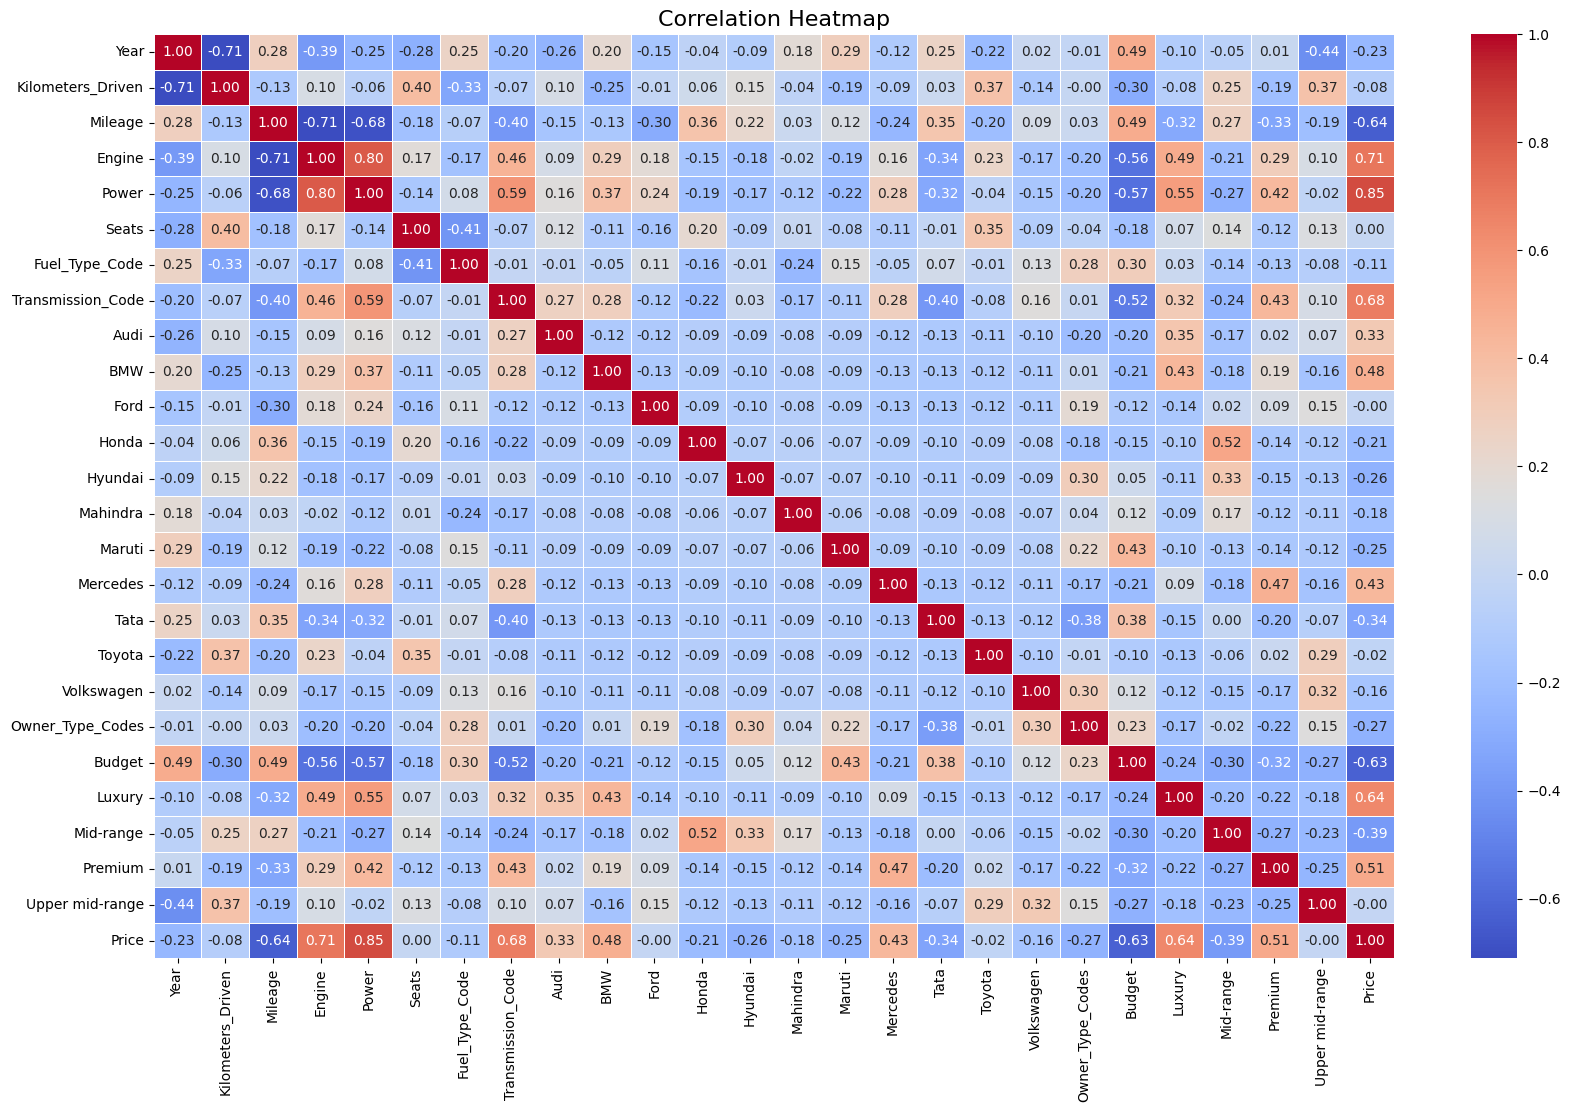

In [22]:
plt.figure(figsize=(20, 12))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap', fontsize=16)

plt.show()

In [23]:
correlation_matrix.Price[np.abs(correlation_matrix.Price) > 0.5]

,Price
Mileage,-0.64
Engine,0.71
Power,0.85
Transmission_Code,0.68
Budget,-0.63
Luxury,0.64
Premium,0.51
Price,1.00


**Висновок:**

Виражену **позитивну** кореляцію мають наступні ознаки:
- Power (0.85)
- Engine (0.71)
- Transmission_Code	(0.68)
- Luxury	(0.64)
- Premium	(0.51)

Виражену **негативну** кореляцію мають наступні ознаки:
- Mileage	(-0.64)
- Budget	(-0.63)

Судячи з того що три з пяти категорій (окрім середніх) класів авто потрапили у виражену кореляцію схиляюсь до думки правильності вибору методу розподілу.

**Завдання 6**. Тренуємо лінійну регресію.
0. Видаліть усі НЕчислові колонки з `X_train`, `X_test`, якщо ще цього не зробили.
1. Натренуйте лінійну регресую з `sklearn` на усіх числових даних тренувального набору `X_train`.
2. Зробіть передбачення на  `X_train`, `X_test`. Знайдіть і виведіть root mean squared error відхилення передбачення від справжніх значень цільової змінної.
3. Побудуйте графік розсіювання передбачень проти реальних даних цільової змінної для тренувального і тестувального наборів даних. Що можете сказати про якість моделі?

In [24]:
X_train = X_train.select_dtypes(include=['number']).drop('Car_ID', axis=1)
X_test = X_test.select_dtypes(include=['number']).drop('Car_ID', axis=1)

display(X_train.head()), display(X_test.head())

,Year,Kilometers_Driven,Mileage,Engine,Power,Seats,Fuel_Type_Code,Transmission_Code,Audi,BMW,Ford,Honda,Hyundai,Mahindra,Maruti,Mercedes,Tata,Toyota,Volkswagen,Owner_Type_Codes,Budget,Luxury,Mid-range,Premium,Upper mid-range
83,2019,22000,18,1498,148,5,1,1,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,1.00,0.00,0.00,0.00,0.00,1.00
55,2018,28000,17,1968,187,5,0,1,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00
26,2018,28000,15,1984,241,5,1,1,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00
54,2017,32000,18,1598,103,5,1,0,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,1.00,1.00,0.00,0.00,0.00,0.00
19,2017,26000,12,1991,241,5,1,1,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,1.00,0.00


,Year,Kilometers_Driven,Mileage,Engine,Power,Seats,Fuel_Type_Code,Transmission_Code,Audi,BMW,Ford,Honda,Hyundai,Mahindra,Maruti,Mercedes,Tata,Toyota,Volkswagen,Owner_Type_Codes,Budget,Luxury,Mid-range,Premium,Upper mid-range
17,2016,38000,15,1395,148,5,1,1,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,1.00
41,2019,26000,20,1086,68,5,1,0,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,2.00,1.00,0.00,0.00,0.00,0.00
92,2017,32000,18,1598,103,5,1,0,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,1.00,1.00,0.00,0.00,0.00,0.00
14,2020,18000,19,1462,103,7,1,0,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00
68,2019,26000,20,1194,94,5,1,0,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,2.00,1.00,0.00,0.00,0.00,0.00


(None, None)

In [25]:
model = LinearRegression().fit(X_train, y_train)
model

LinearRegression()

In [26]:
y_pred_train = model.predict(X_train)
y_pred_test = model.predict(X_test)

In [27]:
loss_train = np.sqrt(mean_squared_error(y_train, y_pred_train))
loss_test = np.sqrt(mean_squared_error(y_test, y_pred_test))
loss_train, loss_test

(np.float64(136714.31122746464), np.float64(186173.18294369112))

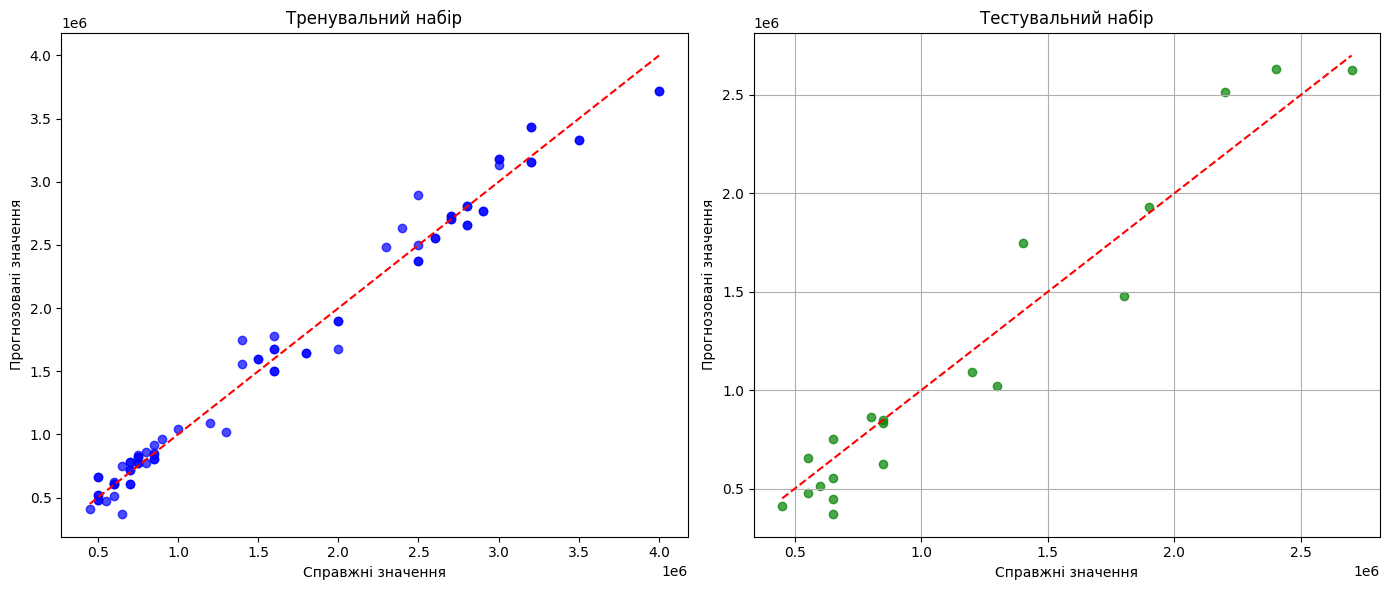

In [28]:
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.scatter(y_train, y_pred_train, alpha=0.7, color='blue')
plt.plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], 'r--')
plt.xlabel("Справжні значення")
plt.ylabel("Прогнозовані значення")
plt.title("Тренувальний набір")

plt.subplot(1, 2, 2)
plt.scatter(y_test, y_pred_test, alpha=0.7, color='green')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Справжні значення")
plt.ylabel("Прогнозовані значення")
plt.title("Тестувальний набір")

plt.tight_layout()
plt.grid(True)
plt.show()

**Спостереження:**

- Червона лінія показує нам ідеальний сценарій де прогнозовані значення ціни будуть співпадати з реальними.
- Так як більшість точок (особливо в тренувальному наборі) знаходяться доволі близько до червоної лінії то вцілому модель працює непогано.
- Деякі значення з тествувального набору дещо відходять від ідеального сценарію, що може свідчити за неточність моделі, малу вибірку даних тестувального набору, наявність нетипових значень
- Бачу, що в тестовому наборі ціни найгірше прогнозовані в середніх класах (там де коефіцієнт кореляції менше 0.5 по модулю) - можливо є сенс погратися з відношенням первних моделей до того чи іншого класу (Mid-range та Upper mid-range)

**Завдання 7**. Ми хочемо проаналізувати як впливає кожен чинник на цілову змінну. Для цього давайте промасштабуємо наші дані.
1. Зробіть масштабування незалежних змінних використовуючи `StandardScaler`. Тренуємо на тренувальних даних, а на тестувальних лише викликаємо `transform`.

2. Натренуйте модель на відмасштабованих даних і перегляньте коефіцієнти моделі. Які колонки є найвпливовішими на формування передбачення з точки зору коефіцієнтів? Проаналізуйте напрям дії найважливіших коефіцієнтів. Чи це логічно з точки зору значення відповідних змінних, що вони впливають на цільову змінну саме в напрямі збільшення / зменшення?

In [29]:
numerical_columns = ['Year', 'Kilometers_Driven', 'Mileage', 'Engine', 'Power', 'Seats']

scaler = StandardScaler()
scaler.fit(X_train[numerical_columns])

X_train[numerical_columns] = scaler.transform(X_train[numerical_columns])
X_test[numerical_columns] = scaler.transform(X_test[numerical_columns])

In [30]:
display(X_train.head(), X_test.head())

,Year,Kilometers_Driven,Mileage,Engine,Power,Seats,Fuel_Type_Code,Transmission_Code,Audi,BMW,Ford,Honda,Hyundai,Mahindra,Maruti,Mercedes,Tata,Toyota,Volkswagen,Owner_Type_Codes,Budget,Luxury,Mid-range,Premium,Upper mid-range
83,0.57,-0.69,0.27,-0.63,-0.23,-0.30,1,1,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,1.00,0.00,0.00,0.00,0.00,1.00
55,-0.32,-0.04,-0.02,0.09,0.25,-0.30,0,1,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00
26,-0.32,-0.04,-0.60,0.11,0.91,-0.30,1,1,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00
54,-1.22,0.40,0.27,-0.48,-0.78,-0.30,1,0,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,1.00,1.00,0.00,0.00,0.00,0.00
19,-1.22,-0.26,-1.48,0.12,0.91,-0.30,1,1,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,1.00,0.00


,Year,Kilometers_Driven,Mileage,Engine,Power,Seats,Fuel_Type_Code,Transmission_Code,Audi,BMW,Ford,Honda,Hyundai,Mahindra,Maruti,Mercedes,Tata,Toyota,Volkswagen,Owner_Type_Codes,Budget,Luxury,Mid-range,Premium,Upper mid-range
17,-2.11,1.05,-0.60,-0.79,-0.23,-0.30,1,1,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,1.00
41,0.57,-0.26,0.86,-1.26,-1.21,-0.30,1,0,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,2.00,1.00,0.00,0.00,0.00,0.00
92,-1.22,0.40,0.27,-0.48,-0.78,-0.30,1,0,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,1.00,1.00,0.00,0.00,0.00,0.00
14,1.46,-1.13,0.57,-0.68,-0.78,2.39,1,0,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00
68,0.57,-0.26,0.86,-1.09,-0.90,-0.30,1,0,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,2.00,1.00,0.00,0.00,0.00,0.00


In [31]:
model_scaled = LinearRegression().fit(X_train, y_train)

In [32]:
weights = pd.DataFrame({
    'feature': np.append(X_train.columns, 'Intercept'),
    'weight': np.append(model_scaled.coef_, model_scaled.intercept_)
})
weights.sort_values('weight', key=abs, ascending=False)

,feature,weight
25,Intercept,1717698.29
21,Luxury,1013611.28
20,Budget,-808081.13
22,Mid-range,-600758.66
23,Premium,425353.20
15,Mercedes,336182.37
4,Power,246367.69
12,Hyundai,-241954.02
18,Volkswagen,-238824.56
8,Audi,212344.59


**Спостереження:**
- Найвпливовішими з точки зору коефіцієнтів є колонки, які визначають клас автомобіля (найвищі позитивні коефіцієнти мають класи - Luxury, Premium;  найнижчі негативні коефіцієнти мають класи - Budget, Mid-range), а також Power.
- Відмічається вплив окремих брендів в ту чи іншу сторону (в залежності до якого класу належать авто цього бренду) Мерседес, Ауді, БМВ з (+) / Hyundai, Volkswagen, Ford з (-)
- Fuel_Type_Code впливає негативно
- Transmission_Code позитивно

Для основних коефіцієнтів напрям їх дії є логічним.

**Завдання 8.** На тих самих відмасштабованих даних натренуйте модель з `statsmodels`. Виведіть звіт і проаналізуйте p-value коефіцієнтів. Які ознаки є стат значущими на рівні значущості 0.05? Напишіть їх список.

In [33]:
X = sm.add_constant(X_train)
model = sm.OLS(y_train, X)
results = model.fit()

results.params.sort_values(key=abs, ascending=False)

,0
const,1330611.35
Luxury,1279733.55
Premium,691475.47
Budget,-541958.86
Mercedes,457147.04
Mid-range,-334636.39
Audi,333309.26
BMW,325630.78
Power,246367.69
Upper mid-range,235997.59


In [34]:
results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  Price   R-squared:                       0.983
Model:                            OLS   Adj. R-squared:                  0.975
Method:                 Least Squares   F-statistic:                     136.8
Date:                Sun, 29 Jun 2025   Prob (F-statistic):           4.68e-41
Time:                        18:09:23   Log-Likelihood:                -1059.6
No. Observations:                  80   AIC:                             2167.
Df Residuals:                      56   BIC:                             2224.
Df Model:                          23                                         
Covariance Type:            nonrobust                                         
=====================================================================================
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const              1.331e+06   4.21e+04     31.628      0.000    1.25e+06    1.41e+06
Year              -2601.7975   4.16e+04     -0.063      0.950   -8.58e+04    8.06e+04
Kilometers_Driven -7.214e+04      4e+04     -1.803      0.077   -1.52e+05    8032.306
Mileage           -9.582e+04   4.26e+04     -2.247      0.029   -1.81e+05   -1.04e+04
Engine            -8.185e+04   4.92e+04     -1.663      0.102    -1.8e+05    1.68e+04
Power              2.464e+05   5.89e+04      4.183      0.000    1.28e+05    3.64e+05
Seats             -2.946e+04   2.96e+04     -0.997      0.323   -8.87e+04    2.97e+04
Fuel_Type_Code    -1.995e+05   7.15e+04     -2.791      0.007   -3.43e+05   -5.63e+04
Transmission_Code  1.303e+05   6.91e+04      1.885      0.065   -8169.282    2.69e+05
Audi               3.333e+05   9.63e+04      3.462      0.001     1.4e+05    5.26e+05
BMW                3.256e+05   9.41e+04      3.460      0.001    1.37e+05    5.14e+05
Ford              -8.126e+04   7.41e+04     -1.096      0.278    -2.3e+05    6.73e+04
Honda               1.44e+05   1.06e+05      1.358      0.180   -6.84e+04    3.56e+05
Hyundai            -1.21e+05   8.55e+04     -1.416      0.162   -2.92e+05    5.02e+04
Mahindra          -2534.2601   1.07e+05     -0.024      0.981   -2.18e+05    2.13e+05
Maruti              1.53e+04   9.26e+04      0.165      0.869    -1.7e+05    2.01e+05
Mercedes           4.571e+05   9.21e+04      4.963      0.000    2.73e+05    6.42e+05
Tata               1.714e+05   8.53e+04      2.009      0.049     492.122    3.42e+05
Toyota             2.065e+05   8.42e+04      2.453      0.017    3.79e+04    3.75e+05
Volkswagen        -1.179e+05    7.7e+04     -1.530      0.132   -2.72e+05    3.64e+04
Owner_Type_Codes   9.751e+04   4.93e+04      1.978      0.053   -1219.995    1.96e+05
Budget             -5.42e+05   1.11e+05     -4.890      0.000   -7.64e+05    -3.2e+05
Luxury              1.28e+06   1.25e+05     10.276      0.000    1.03e+06    1.53e+06
Mid-range         -3.346e+05   8.52e+04     -3.926      0.000   -5.05e+05   -1.64e+05
Premium            6.915e+05   8.84e+04      7.819      0.000    5.14e+05    8.69e+05
Upper mid-range     2.36e+05   5.72e+04      4.122      0.000    1.21e+05    3.51e+05
==============================================================================
Omnibus:                        1.592   Durbin-Watson:                   2.105
Prob(Omnibus):                  0.451   Jarque-Bera (JB):                0.974
Skew:                          -0.132   Prob(JB):                        0.615
Kurtosis:                       3.472   Cond. No.                     1.67e+16
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The smalles

In [35]:
df_summary = results.summary2().tables[1]
df_summary_p_005 = df_summary[df_summary['P>|t|']<0.05]
df_summary_p_005['P>|t|']

,P>|t|
const,0.00
Mileage,0.03
Power,0.00
Fuel_Type_Code,0.01
Audi,0.00
BMW,0.00
Mercedes,0.00
Tata,0.05
Toyota,0.02
Budget,0.00


**Завдання 9**. Натренуйте лінійну регресію з `statsmodels` тільки на ознаках, які виявлись стат. значущими в попередньому завданні. Проаналізуйте показники моделі. Чи значно змінились R2 і Adj. R-squared?

In [36]:
p_005_columns = df_summary_p_005.index

model2 = sm.OLS(y_train, X[p_005_columns])
results2 = model2.fit()

results2.params.sort_values(key=abs, ascending=False)

,0
const,1386712.51
Luxury,1297449.96
Premium,784187.04
Budget,-555556.52
Mercedes,501532.98
BMW,426404.16
Mid-range,-379340.65
Audi,330745.82
Upper mid-range,239972.68
Power,185003.62


In [37]:
results2.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  Price   R-squared:                       0.977
Model:                            OLS   Adj. R-squared:                  0.973
Method:                 Least Squares   F-statistic:                     237.8
Date:                Sun, 29 Jun 2025   Prob (F-statistic):           5.75e-50
Time:                        18:16:43   Log-Likelihood:                -1070.4
No. Observations:                  80   AIC:                             2167.
Df Residuals:                      67   BIC:                             2198.
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
===================================================================================
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const            1.387e+06   3.96e+04     34.984      0.000    1.31e+06    1.47e+06
Mileage         -3.527e+04   2.96e+04     -1.191      0.238   -9.44e+04    2.38e+04
Power             1.85e+05   4.77e+04      3.877      0.000    8.97e+04     2.8e+05
Fuel_Type_Code  -5.109e+04    4.6e+04     -1.110      0.271   -1.43e+05    4.08e+04
Audi             3.307e+05   1.08e+05      3.053      0.003    1.15e+05    5.47e+05
BMW              4.264e+05   1.11e+05      3.850      0.000    2.05e+05    6.47e+05
Mercedes         5.015e+05   1.05e+05      4.771      0.000    2.92e+05    7.11e+05
Tata              1.73e+04   6.45e+04      0.268      0.790   -1.12e+05    1.46e+05
Toyota           4.705e+04   7.68e+04      0.613      0.542   -1.06e+05       2e+05
Budget          -5.556e+05   8.74e+04     -6.358      0.000    -7.3e+05   -3.81e+05
Luxury           1.297e+06   1.15e+05     11.248      0.000    1.07e+06    1.53e+06
Mid-range       -3.793e+05   6.57e+04     -5.772      0.000   -5.11e+05   -2.48e+05
Premium          7.842e+05    7.4e+04     10.603      0.000    6.37e+05    9.32e+05
Upper mid-range    2.4e+05   4.63e+04      5.180      0.000    1.48e+05    3.32e+05
==============================================================================
Omnibus:                        0.741   Durbin-Watson:                   1.760
Prob(Omnibus):                  0.690   Jarque-Bera (JB):                0.313
Skew:                          -0.110   Prob(JB):                        0.855
Kurtosis:                       3.213   Cond. No.                     1.55e+16
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The smallest eigenvalue is 6.25e-31. This might indicate that there are
strong multicollinearity problems or that the design matrix is singular.
"""

**Спостереження:**

В другої моделі R2 і Adj. R-squared трохи нижчі в порівнянні з першою, але це все ще дуже високі значення, обидві моделі добре підходять для даних.

**Завдання 10**. Натренуйте лінійну регресію з `statsmodels` на усіх ознаках з масштабованого `X_train`, у яких p_value в завданні 7 менше за `0.25`. Ми таким чином помʼякшили критерій відбору ознак. Проаналізуйте показники моделі. Чи значно змінились R2 і Adj. R-squared порівняно з завданням 7? Яку модель з останніх 3х завдань ви б лишили для використання?

In [38]:
df_summary_p_025 = df_summary[df_summary['P>|t|']<0.25]
p_025_columns = df_summary_p_025.index

model3 = sm.OLS(y_train, X[p_025_columns])
results3 = model3.fit()

results3.params.sort_values(key=abs, ascending=False)

,0
const,1299548.30
Luxury,1231059.26
Premium,658976.61
Mercedes,521400.93
Budget,-505144.56
BMW,392725.03
Audi,371858.16
Mid-range,-321748.50
Power,258543.96
Upper mid-range,236405.50


In [39]:
results3.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  Price   R-squared:                       0.982
Model:                            OLS   Adj. R-squared:                  0.976
Method:                 Least Squares   F-statistic:                     172.4
Date:                Sun, 29 Jun 2025   Prob (F-statistic):           3.94e-45
Time:                        18:20:22   Log-Likelihood:                -1060.7
No. Observations:                  80   AIC:                             2161.
Df Residuals:                      60   BIC:                             2209.
Df Model:                          19                                         
Covariance Type:            nonrobust                                         
=====================================================================================
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                1.3e+06   6.08e+04     21.372      0.000    1.18e+06    1.42e+06
Kilometers_Driven -7.133e+04   2.76e+04     -2.584      0.012   -1.27e+05   -1.61e+04
Mileage           -7.843e+04   3.44e+04     -2.277      0.026   -1.47e+05   -9536.906
Engine            -8.236e+04   4.25e+04     -1.936      0.058   -1.67e+05    2738.515
Power              2.585e+05   5.52e+04      4.684      0.000    1.48e+05    3.69e+05
Fuel_Type_Code     -1.81e+05   5.85e+04     -3.095      0.003   -2.98e+05    -6.4e+04
Transmission_Code  1.448e+05   6.15e+04      2.353      0.022    2.17e+04    2.68e+05
Audi               3.719e+05   1.21e+05      3.077      0.003     1.3e+05    6.14e+05
BMW                3.927e+05   1.13e+05      3.478      0.001    1.67e+05    6.19e+05
Honda               1.22e+05   1.13e+05      1.079      0.285   -1.04e+05    3.48e+05
Hyundai           -9.671e+04   9.04e+04     -1.069      0.289   -2.78e+05    8.42e+04
Mercedes           5.214e+05   1.09e+05      4.789      0.000    3.04e+05    7.39e+05
Tata               1.545e+05   9.31e+04      1.660      0.102   -3.16e+04    3.41e+05
Toyota             2.192e+05   9.62e+04      2.279      0.026    2.68e+04    4.12e+05
Volkswagen        -8.961e+04   8.58e+04     -1.045      0.300   -2.61e+05    8.19e+04
Owner_Type_Codes   7.508e+04   4.49e+04      1.671      0.100   -1.48e+04    1.65e+05
Budget            -5.051e+05   9.08e+04     -5.562      0.000   -6.87e+05   -3.23e+05
Luxury             1.231e+06   1.19e+05     10.346      0.000    9.93e+05    1.47e+06
Mid-range         -3.217e+05   7.21e+04     -4.462      0.000   -4.66e+05   -1.77e+05
Premium             6.59e+05   8.03e+04      8.207      0.000    4.98e+05     8.2e+05
Upper mid-range    2.364e+05   5.06e+04      4.674      0.000    1.35e+05    3.38e+05
==============================================================================
Omnibus:                        1.062   Durbin-Watson:                   2.149
Prob(Omnibus):                  0.588   Jarque-Bera (JB):                0.684
Skew:                          -0.219   Prob(JB):                        0.710
Kurtosis:                       3.119   Cond. No.                     1.62e+16
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The smallest eigenvalue is 8.42e-31. This might indicate that there are
strong multicollinearity problems or that the design matrix is singular.
"""

**Спостереження:**

- Третя модель має майже такий самий R-squared як і перша (0.982 проти 0.983), при цьому трохи вищий Adj. R-squared (0.976 проти 0.975).
- Також третя модель має кращі інші показники - F-statistic, AIC, BIC. Для використання я би обрав третю, оскільки вона пропонує найкращий баланс точності і сладності моделі.